# Notebook 02 — Classification Methods

**Goal:** Run all classification methods against qualitative ground truth labels and compare.

**Methods (in order of supervision level):**

| # | Method | Model | Supervision | Primary use |
|---|--------|-------|-------------|-------------|
| A | VADER lexicon | Rule-based | None | Baseline — proves basic sentiment is insufficient |
| B | Cardiff RoBERTa | `cardiffnlp/twitter-roberta-base-sentiment` | Pre-trained | Informal-text sentiment |
| C | Hartmann emotion | `j-hartmann/emotion-english-distilroberta-base` | Pre-trained | 7-emotion → maps to codes |
| D | Zero-shot NLI | `MoritzLaurer/deberta-v3-base-zeroshot-v1.1-all-33` | None (NLI) | Code definitions as hypotheses |
| E | SetFit few-shot | MiniLM / MPNet / BGE backbones | Few-shot | Small-data contrastive fine-tuning |

**GPU notes:** Transformer inference uses FP16 on CUDA where supported. SetFit starts with a low-VRAM MiniLM backbone and only attempts larger backbones if memory allows.  
**RTX 4060 8 GB VRAM:** prefer MiniLM for reliable completion; MPNet/BGE are robustness checks rather than guaranteed runs.

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')  # prevent OpenMP duplicate-runtime segfault (torch+MKL/numba)

import pickle, pathlib, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import (classification_report, cohen_kappa_score,
                               f1_score, precision_score, recall_score,
                               confusion_matrix, ConfusionMatrixDisplay)
warnings.filterwarnings('ignore')

DATA_DIR   = pathlib.Path('data')
OUTPUT_DIR = pathlib.Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

with open(DATA_DIR / 'config.pkl', 'rb') as f:
    cfg = pickle.load(f)
DECISION_CODES   = cfg['DECISION_CODES']
CODE_DEFINITIONS = cfg['CODE_DEFINITIONS']
DEVICE           = cfg['DEVICE']
SEED             = cfg['SEED']
CODE_NAMES       = list(DECISION_CODES.keys())

dm_df   = pd.read_csv(DATA_DIR / 'decision_making.csv')
DOCS    = dm_df['response_text'].tolist()
LABELS  = dm_df['label'].values

print(f'Decision-making docs: {len(DOCS)}')
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── Shared evaluation function ────────────────────────────────────────────────
all_results = {}   # collects {method_name: {'preds': arr, 'metrics': dict}}

def evaluate_and_store(name, y_true, y_pred, target_names):
    report = classification_report(y_true, y_pred, target_names=target_names,
                                    output_dict=True, zero_division=0)
    kappa  = cohen_kappa_score(y_true, y_pred)
    macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    macro_recall    = recall_score(y_true, y_pred, average='macro', zero_division=0)
    macro_f1        = f1_score(y_true, y_pred, average='macro', zero_division=0)
    wt_precision    = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    wt_recall       = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    wt_f1           = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    all_results[name] = {
        'preds':               y_pred,
        'true':                y_true,
        'kappa':               round(kappa,           3),
        'macro_precision':     round(macro_precision, 3),
        'macro_recall':        round(macro_recall,    3),
        'macro_f1':            round(macro_f1,        3),
        'weighted_precision':  round(wt_precision,    3),
        'weighted_recall':     round(wt_recall,       3),
        'weighted_f1':         round(wt_f1,           3),
        'per_class':           {n: report[n] for n in target_names if n in report},
    }
    print(f'\n══ {name} ══')
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))
    kappa_str = ('poor' if kappa<0.2 else 'fair' if kappa<0.4 else
                 'moderate' if kappa<0.6 else 'substantial' if kappa<0.8 else 'near-perfect')
    print(f'Cohen\'s κ = {kappa:.3f}  ({kappa_str})')
    print(f'Macro precision = {macro_precision:.3f} | Macro recall = {macro_recall:.3f} | Macro F1 = {macro_f1:.3f}')
    print(f'Weighted precision = {wt_precision:.3f} | Weighted recall = {wt_recall:.3f} | Weighted F1 = {wt_f1:.3f}')
    return all_results[name]

Decision-making docs: 278
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
# ── Safetensors guard ─────────────────────────────────────────────────────────
# transformers >=4.5x refuses to load pickle (.bin) weights unless torch >= 2.6
# (CVE-2025-32434). Some models here (Cardiff sentiment, Hartmann emotion) ship
# ONLY .bin. This helper returns a safetensors path: the model id unchanged if it
# already has safetensors, otherwise a ONE-TIME local conversion under models/st/.
# (Keeps torch 2.5.1 untouched.)
import pathlib
from transformers import AutoConfig, AutoModelForSequenceClassification, AutoTokenizer
from huggingface_hub import list_repo_files, hf_hub_download

def ensure_safetensors(model_id, out_root='models/st'):
    if any(f.endswith('.safetensors') for f in list_repo_files(model_id)):
        return model_id                                   # already safe — use as-is
    out = pathlib.Path(out_root) / model_id.replace('/', '__')
    if not (out / 'model.safetensors').exists():
        cfg   = AutoConfig.from_pretrained(model_id)
        model = AutoModelForSequenceClassification.from_config(cfg)   # no torch.load
        sd = torch.load(hf_hub_download(model_id, 'pytorch_model.bin'),
                        weights_only=True, map_location='cpu')
        model.load_state_dict(sd, strict=False)           # ignores extra buffers (pooler/position_ids)
        out.mkdir(parents=True, exist_ok=True)
        model.save_pretrained(out, safe_serialization=True)
        AutoTokenizer.from_pretrained(model_id).save_pretrained(out)
        print(f'Converted {model_id} -> {out} (safetensors)')
    return str(out)

## A. VADER — lexicon baseline


══ VADER heuristic (decision codes) ══
                    precision    recall  f1-score   support

voluntary_informed       0.24      0.56      0.34        36
 feeling_pressured       0.50      0.05      0.09        80
 insufficient_info       0.56      0.52      0.54       145
     too_much_info       0.00      0.00      0.00         9
        no_consent       0.00      0.00      0.00         8

          accuracy                           0.36       278
         macro avg       0.26      0.23      0.19       278
      weighted avg       0.47      0.36      0.35       278

Cohen's κ = 0.078  (poor)
Macro precision = 0.261 | Macro recall = 0.226 | Macro F1 = 0.194
Weighted precision = 0.469 | Weighted recall = 0.360 | Weighted F1 = 0.353


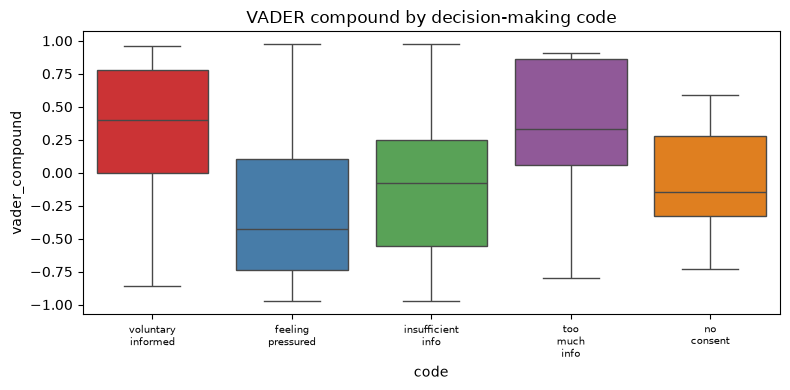


NOTE: VADER baseline is expected to perform poorly on decision codes.
Poor performance here motivates transformer-based approaches.


In [3]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# VADER gives: neg, neu, pos, compound (-1 to +1).
# Here it is used only as a weak decision-code baseline, not as a separate polarity task.
analyzer = SentimentIntensityAnalyzer()

# ── Decision-making subset: heuristic 5-class mapping ────────────────────────
# This is deliberately crude — it shows why generic sentiment is insufficient
# for nuanced consent/agency codes.
vader_dm_preds = []
for doc in DOCS:
    s = analyzer.polarity_scores(doc)
    c = s['compound']
    neg = s['neg']
    # Heuristic: high negativity → pressured; neutral → insufficient_info (dominant class)
    if c >= 0.2:                    pred = 0  # voluntary_informed
    elif c <= -0.4 and neg > 0.3:   pred = 1  # feeling_pressured
    elif c <= -0.1 and neg > 0.15:  pred = 4  # no_consent
    else:                            pred = 2  # insufficient_info (default)
    vader_dm_preds.append(pred)

evaluate_and_store('VADER heuristic (decision codes)', LABELS,
                   np.array(vader_dm_preds), CODE_NAMES)

dm_df['vader_compound'] = [analyzer.polarity_scores(d)['compound'] for d in DOCS]
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=dm_df, x='code', y='vader_compound', ax=ax, palette='Set1')
ax.set_xticklabels([c.replace('_','\n') for c in CODE_NAMES], fontsize=7)
ax.set_title('VADER compound by decision-making code')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vader_scores.png', dpi=130, bbox_inches='tight')
plt.show()
print('\nNOTE: VADER baseline is expected to perform poorly on decision codes.')
print('Poor performance here motivates transformer-based approaches.')

## B. Cardiff Twitter-RoBERTa — informal text sentiment

In [4]:
from transformers import pipeline, AutoModelForSequenceClassification, AutoTokenizer

CARDIFF_MODEL = 'cardiffnlp/twitter-roberta-base-sentiment-latest'
print(f'Loading {CARDIFF_MODEL}...')

cardiff_pipe = pipeline(
    'text-classification',
    model=ensure_safetensors(CARDIFF_MODEL),   # .bin-only -> local safetensors
    device=0 if DEVICE == 'cuda' else -1,
    torch_dtype=torch.float16 if DEVICE == 'cuda' else torch.float32,
    top_k=None,       # return all scores
    truncation=True,
    max_length=512,
)

def run_cardiff(docs):
    results = []
    # Batch inference for GPU efficiency
    batch_size = 32
    for i in range(0, len(docs), batch_size):
        batch  = docs[i:i+batch_size]
        output = cardiff_pipe(batch)
        results.extend(output)
    return results

# Run on decision-making subset — shows limitation of sentiment for nuanced codes
print('Running Cardiff RoBERTa on decision-making subset...')
t0 = time.time()
cardiff_dm_raw = run_cardiff(DOCS)
print(f'Done in {time.time()-t0:.1f}s')

def cardiff_to_5class(raw_result):
    """Map sentiment scores to 5 consent codes — heuristic, expect poor performance."""
    scores = {r['label'].lower(): r['score'] for r in raw_result}
    pos = scores.get('positive', 0)
    neg = scores.get('negative', 0)
    if pos > 0.7:   return 0   # voluntary_informed
    if neg > 0.7:   return 1   # feeling_pressured
    return 2                    # insufficient_info (dominant class)

cardiff_dm_preds = np.array([cardiff_to_5class(r) for r in cardiff_dm_raw])
evaluate_and_store('Cardiff RoBERTa (decision codes heuristic)', LABELS,
                   cardiff_dm_preds, CODE_NAMES)

del cardiff_pipe
if DEVICE == 'cuda': torch.cuda.empty_cache()

Loading cardiffnlp/twitter-roberta-base-sentiment-latest...


`torch_dtype` is deprecated! Use `dtype` instead!
Device set to use cuda:0


Running Cardiff RoBERTa on decision-making subset...
Done in 2.4s

══ Cardiff RoBERTa (decision codes heuristic) ══
                    precision    recall  f1-score   support

voluntary_informed       0.71      0.33      0.45        36
 feeling_pressured       0.38      0.59      0.46        80
 insufficient_info       0.51      0.48      0.49       145
     too_much_info       0.00      0.00      0.00         9
        no_consent       0.00      0.00      0.00         8

          accuracy                           0.46       278
         macro avg       0.32      0.28      0.28       278
      weighted avg       0.46      0.46      0.45       278

Cohen's κ = 0.112  (poor)
Macro precision = 0.318 | Macro recall = 0.279 | Macro F1 = 0.280
Weighted precision = 0.464 | Weighted recall = 0.460 | Weighted F1 = 0.447


## C. Hartmann emotion model — 7 emotions mapped to consent codes

Loading j-hartmann/emotion-english-distilroberta-base...


Device set to use cuda:0


Running Hartmann emotion model on decision-making subset...
Done in 1.2s

══ Hartmann Emotion (decision codes) ══
                    precision    recall  f1-score   support

voluntary_informed       0.28      0.67      0.39        36
 feeling_pressured       0.67      0.03      0.05        80
 insufficient_info       0.62      0.33      0.43       145
     too_much_info       0.07      0.56      0.13         9
        no_consent       0.02      0.12      0.04         8

          accuracy                           0.29       278
         macro avg       0.33      0.34      0.21       278
      weighted avg       0.56      0.29      0.30       278

Cohen's κ = 0.109  (poor)
Macro precision = 0.332 | Macro recall = 0.341 | Macro F1 = 0.208
Weighted precision = 0.556 | Weighted recall = 0.288 | Weighted F1 = 0.295


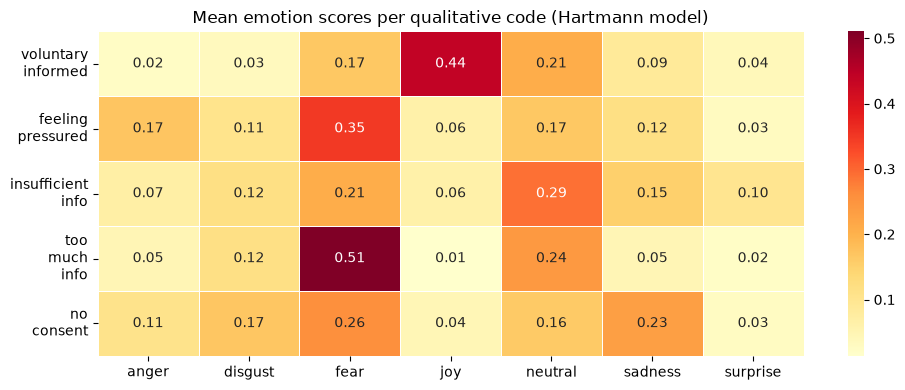

In [5]:
HARTMANN_MODEL = 'j-hartmann/emotion-english-distilroberta-base'
print(f'Loading {HARTMANN_MODEL}...')
# Outputs: anger, disgust, fear, joy, neutral, sadness, surprise

hartmann_pipe = pipeline(
    'text-classification',
    model=ensure_safetensors(HARTMANN_MODEL),   # .bin-only -> local safetensors
    device=0 if DEVICE == 'cuda' else -1,
    torch_dtype=torch.float16 if DEVICE == 'cuda' else torch.float32,
    top_k=None,
    truncation=True,
    max_length=512,
)

print('Running Hartmann emotion model on decision-making subset...')
t0 = time.time()
hartmann_raw = []
for i in range(0, len(DOCS), 32):
    hartmann_raw.extend(hartmann_pipe(DOCS[i:i+32]))
print(f'Done in {time.time()-t0:.1f}s')

# ── Emotion → decision code mapping (theoretically motivated) ────────────────
# voluntary_informed : joy, neutral  (calm/supportive account)
# feeling_pressured  : anger, fear   (coercion induces fear/anger)
# insufficient_info  : sadness, surprise  (disappointment, being caught off-guard)
# too_much_info      : fear          (anxiety from unbalanced risk information)
# no_consent         : anger, disgust (violation)
#
# The mapping is a *hypothesis* — poor performance is as informative as good performance.

def emotion_to_consent_code(raw_result):
    scores = {r['label'].lower(): r['score'] for r in raw_result}
    anger   = scores.get('anger',   0)
    disgust = scores.get('disgust', 0)
    fear    = scores.get('fear',    0)
    joy     = scores.get('joy',     0)
    neutral = scores.get('neutral', 0)
    sadness = scores.get('sadness', 0)
    surprise= scores.get('surprise',0)

    # Dominant emotion determines the code
    if joy + neutral > 0.55:                    return 0  # voluntary_informed
    if anger + disgust > 0.55:                  return 4  # no_consent
    if anger + fear > 0.50 and anger > fear:    return 1  # feeling_pressured
    if fear > 0.45:                             return 3  # too_much_info
    return 2                                               # insufficient_info

hartmann_preds_dm = np.array([emotion_to_consent_code(r) for r in hartmann_raw])
evaluate_and_store('Hartmann Emotion (decision codes)', LABELS,
                   hartmann_preds_dm, CODE_NAMES)

# ── Emotion score heatmap per true code ──────────────────────────────────────
emotion_labels = ['anger','disgust','fear','joy','neutral','sadness','surprise']
emotion_matrix = np.zeros((len(CODE_NAMES), len(emotion_labels)))
for i, code_idx in enumerate(DECISION_CODES.values()):
    mask_c = LABELS == code_idx
    if mask_c.sum() == 0: continue
    for j, emo in enumerate(emotion_labels):
        vals = []
        for raw in [hartmann_raw[k] for k in range(len(DOCS)) if mask_c[k]]:
            s = {r['label'].lower(): r['score'] for r in raw}
            vals.append(s.get(emo, 0))
        emotion_matrix[i, j] = np.mean(vals)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(emotion_matrix, xticklabels=emotion_labels,
            yticklabels=[c.replace('_','\n') for c in CODE_NAMES],
            annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            linewidths=0.4)
ax.set_title('Mean emotion scores per qualitative code (Hartmann model)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hartmann_emotion_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

del hartmann_pipe
if DEVICE == 'cuda': torch.cuda.empty_cache()

## D. Zero-shot DeBERTa-NLI — HSE consent definitions as hypotheses

Loading MoritzLaurer/deberta-v3-base-zeroshot-v1.1-all-33...
This is the most principled zero-shot model for this task:
The HSE consent framework definitions ARE hypotheses — this is textual entailment.


Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



Candidate labels (hypotheses):
  [voluntary_informed]: The woman felt well informed about the risks, benefits and alternatives and made...
  [feeling_pressured]: The woman felt pressured, bullied, threatened, scared, gaslit, or coerced into a...
  [insufficient_info]: The woman did not receive enough information about the risks, benefits and alter...
  [too_much_info]: The woman felt overwhelmed or made more anxious by too much negative information...
  [no_consent]: Induction or an induction procedure was performed without asking for or obtainin...

Running zero-shot classification...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Done in 25.7s

══ Zero-shot DeBERTa-v3 NLI (decision codes) ══
                    precision    recall  f1-score   support

voluntary_informed       0.80      0.56      0.66        36
 feeling_pressured       0.75      0.15      0.25        80
 insufficient_info       0.89      0.28      0.43       145
     too_much_info       0.44      0.44      0.44         9
        no_consent       0.04      1.00      0.08         8

          accuracy                           0.31       278
         macro avg       0.59      0.49      0.37       278
      weighted avg       0.80      0.31      0.40       278

Cohen's κ = 0.198  (poor)
Macro precision = 0.586 | Macro recall = 0.487 | Macro F1 = 0.373
Weighted precision = 0.800 | Weighted recall = 0.306 | Weighted F1 = 0.398


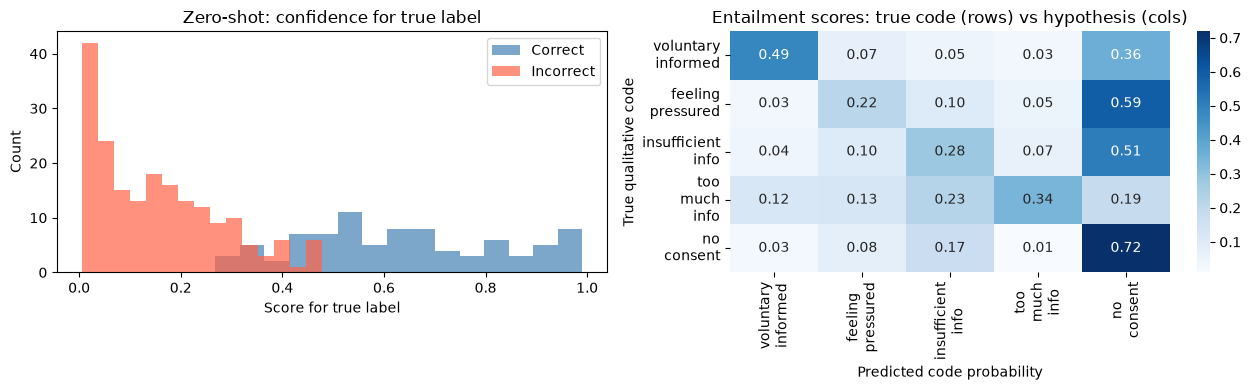

In [6]:
DEBERTA_MODEL = 'MoritzLaurer/deberta-v3-base-zeroshot-v1.1-all-33'
print(f'Loading {DEBERTA_MODEL}...')
print('This is the most principled zero-shot model for this task:')
print('The HSE consent framework definitions ARE hypotheses — this is textual entailment.')

zs_pipe = pipeline(
    'zero-shot-classification',
    model=DEBERTA_MODEL,
    device=0 if DEVICE == 'cuda' else -1,
    torch_dtype=torch.float16 if DEVICE == 'cuda' else torch.float32,
)

# Use the full code definitions as candidate labels — not just the code names
ZS_CANDIDATE_LABELS = list(CODE_DEFINITIONS.values())
ZS_CODE_ORDER       = list(CODE_DEFINITIONS.keys())

print(f'\nCandidate labels (hypotheses):')
for code, defn in CODE_DEFINITIONS.items():
    print(f'  [{code}]: {defn[:80]}...')

print('\nRunning zero-shot classification...')
t0 = time.time()
zs_preds = []
zs_scores_all = []

for doc in DOCS:
    result = zs_pipe(doc, candidate_labels=ZS_CANDIDATE_LABELS, multi_label=False)
    best_label = result['labels'][0]
    pred_code  = ZS_CODE_ORDER[ZS_CANDIDATE_LABELS.index(best_label)]
    pred_idx   = DECISION_CODES[pred_code]
    zs_preds.append(pred_idx)
    # Store full score distribution for analysis
    score_dict = dict(zip(result['labels'], result['scores']))
    ordered_scores = [score_dict[ZS_CANDIDATE_LABELS[DECISION_CODES[c]]] for c in CODE_NAMES]
    zs_scores_all.append(ordered_scores)

zs_preds = np.array(zs_preds)
zs_scores_all = np.array(zs_scores_all)
print(f'Done in {time.time()-t0:.1f}s')

evaluate_and_store('Zero-shot DeBERTa-v3 NLI (decision codes)', LABELS, zs_preds, CODE_NAMES)

# ── Confidence distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confidence of correct vs incorrect predictions
correct_conf   = zs_scores_all[np.arange(len(LABELS)), LABELS][zs_preds == LABELS]
incorrect_conf = zs_scores_all[np.arange(len(LABELS)), LABELS][zs_preds != LABELS]
axes[0].hist(correct_conf,   bins=15, alpha=0.7, color='steelblue', label='Correct')
axes[0].hist(incorrect_conf, bins=15, alpha=0.7, color='tomato',    label='Incorrect')
axes[0].set_xlabel('Score for true label')
axes[0].set_ylabel('Count')
axes[0].set_title('Zero-shot: confidence for true label')
axes[0].legend()

# Per-code mean confidence scores (entailment matrix)
code_conf_matrix = np.zeros((len(CODE_NAMES), len(CODE_NAMES)))
for true_idx in range(len(CODE_NAMES)):
    mask_t = LABELS == true_idx
    if mask_t.sum() > 0:
        code_conf_matrix[true_idx] = zs_scores_all[mask_t].mean(axis=0)

sns.heatmap(code_conf_matrix, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[c.replace('_','\n') for c in CODE_NAMES],
            yticklabels=[c.replace('_','\n') for c in CODE_NAMES],
            ax=axes[1])
axes[1].set_xlabel('Predicted code probability')
axes[1].set_ylabel('True qualitative code')
axes[1].set_title('Entailment scores: true code (rows) vs hypothesis (cols)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'zeroshot_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

del zs_pipe
if DEVICE == 'cuda': torch.cuda.empty_cache()

## E. SetFit few-shot fine-tuning

In [7]:
from setfit import SetFitModel, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.model_selection import StratifiedKFold

print('SetFit few-shot classification')
print('Uses contrastive sentence-pair training for small labelled datasets.')
print('Runs candidate backbones from low-VRAM to stronger semantic encoders.\n')

SETFIT_MODELS = [
    ('sentence-transformers/all-MiniLM-L6-v2', 'MiniLM low-VRAM baseline'),
    ('sentence-transformers/all-mpnet-base-v2', 'MPNet stronger semantic baseline'),
    ('BAAI/bge-base-en-v1.5', 'BGE robustness check'),
]
N_FOLDS = 5  # stratified k-fold (handles rare classes better than LOO at small n)

def run_setfit_cv(model_id, model_label):
    print(f'\n════ SetFit backbone: {model_label} ({model_id}) ════')
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    preds_all = np.zeros(len(LABELS), dtype=int)
    fold_ids = np.full(len(LABELS), -1, dtype=int)
    fold_kappas = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(DOCS, LABELS)):
        print(f'\n── Fold {fold+1}/{N_FOLDS} ──')
        train_docs   = [DOCS[i] for i in train_idx]
        train_labels = [int(LABELS[i]) for i in train_idx]
        test_docs    = [DOCS[i] for i in test_idx]

        train_ds = Dataset.from_dict({'text': train_docs, 'label': train_labels})

        model = SetFitModel.from_pretrained(
            model_id,
            labels=list(range(len(CODE_NAMES))),
            device=DEVICE,
        )

        args = TrainingArguments(
            num_epochs=1,
            batch_size=4,          # conservative for RTX 4060 8 GB
            num_iterations=20,
            seed=SEED,
        )

        trainer = Trainer(
            model=model,
            args=args,
            train_dataset=train_ds,
        )
        trainer.train()

        fold_preds = model.predict(test_docs)
        preds_all[test_idx] = np.array(fold_preds).astype(int)
        fold_ids[test_idx] = fold + 1

        fold_kappa = cohen_kappa_score(LABELS[test_idx], preds_all[test_idx])
        fold_kappas.append(fold_kappa)
        print(f'  Fold {fold+1} κ = {fold_kappa:.3f}')

        del model, trainer
        if DEVICE == 'cuda': torch.cuda.empty_cache()

    print(f'\nSetFit {model_label} cross-validation κ: {np.mean(fold_kappas):.3f} ± {np.std(fold_kappas):.3f}')
    result_name = f'SetFit {model_label} 5-fold CV'
    evaluate_and_store(result_name, LABELS, preds_all, CODE_NAMES)
    all_results[result_name]['cv_fold'] = fold_ids
    all_results[result_name]['model_id'] = model_id
    all_results[result_name]['model_label'] = model_label
    all_results[result_name]['n_folds'] = N_FOLDS
    return result_name, preds_all

setfit_successes = []
setfit_failures = []
for model_id, model_label in SETFIT_MODELS:
    try:
        result_name, preds = run_setfit_cv(model_id, model_label)
        setfit_successes.append((result_name, preds))
    except RuntimeError as e:
        msg = str(e).split('\n')[0]
        print(f'\nSkipping {model_label}: {msg}')
        setfit_failures.append((model_label, msg))
        if DEVICE == 'cuda': torch.cuda.empty_cache()

if not setfit_successes:
    raise RuntimeError('No SetFit backbone completed. Try rerunning with DEVICE="cpu" or reduce batch_size/num_iterations.')

best_setfit_name = max(setfit_successes, key=lambda item: all_results[item[0]]['macro_f1'])[0]
setfit_preds_all = dict(setfit_successes)[best_setfit_name]
print(f'\nBest completed SetFit run by macro-F1: {best_setfit_name}')

SetFit few-shot classification
Uses contrastive sentence-pair training for small labelled datasets.
Runs candidate backbones from low-VRAM to stronger semantic encoders.


════ SetFit backbone: MiniLM low-VRAM baseline (sentence-transformers/all-MiniLM-L6-v2) ════

── Fold 1/5 ──


model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
Map: 100%|██████████| 222/222 [00:00<00:00, 23760.73 examples/s]
***** Running training *****
  Num unique pairs = 8880
  Batch size = 4
  Num epochs = 1


Step,Training Loss
1,0.510400
50,0.311200
100,0.285500
150,0.262700
200,0.248200
250,0.237600
300,0.224600
350,0.196900
400,0.178500
450,0.157300


  Fold 1 κ = 0.430

── Fold 2/5 ──


model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
Map: 100%|██████████| 222/222 [00:00<00:00, 15922.02 examples/s]
***** Running training *****
  Num unique pairs = 8880
  Batch size = 4
  Num epochs = 1


...

Step,Training Loss
1,0.211000
50,0.274900
100,0.253700
150,0.240000
200,0.193300
250,0.162200
300,0.145000
350,0.117100
400,0.055600
450,0.046100


  Fold 4 κ = 0.517

── Fold 5/5 ──


model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
Map: 100%|██████████| 223/223 [00:00<00:00, 8492.04 examples/s]
***** Running training *****
  Num unique pairs = 8920
  Batch size = 4
  Num epochs = 1


Step,Training Loss
1,0.165100
50,0.275100
100,0.236300
150,0.236800
200,0.212400
250,0.172700
300,0.172600
350,0.107800
400,0.086400
450,0.069100


  Fold 5 κ = 0.508

SetFit BGE robustness check cross-validation κ: 0.514 ± 0.064

══ SetFit BGE robustness check 5-fold CV ══
                    precision    recall  f1-score   support

voluntary_informed       0.78      0.58      0.67        36
 feeling_pressured       0.66      0.60      0.63        80
 insufficient_info       0.72      0.87      0.79       145
     too_much_info       1.00      0.44      0.62         9
        no_consent       0.00      0.00      0.00         8

          accuracy                           0.72       278
         macro avg       0.63      0.50      0.54       278
      weighted avg       0.70      0.72      0.70       278

Cohen's κ = 0.514  (moderate)
Macro precision = 0.632 | Macro recall = 0.499 | Macro F1 = 0.540
Weighted precision = 0.700 | Weighted recall = 0.716 | Weighted F1 = 0.699

Best completed SetFit run by macro-F1: SetFit MPNet stronger semantic baseline 5-fold CV


## F. Load saved final SetFit model and recover reportable CV metrics

The 5-fold cross-validation results above remain the reportable evaluation metrics. This cell loads the saved final MPNet SetFit, recovers the completed 5-fold CV precision/recall/F1 metrics, and saves those recovered reportable metrics for downstream notebook use. It never retrains the final classifier.

In [3]:
# -- Load saved SetFit model for Notebook 03 reuse -----------------------------
# Keep cross-validation metrics as the unbiased evaluation. This cell only
# loads the saved classifier and recovers reportable CV metrics from existing
# notebook artefacts or executed outputs.
from setfit import SetFitModel
import json
import re

FINAL_SETFIT_MODEL_ID = 'sentence-transformers/all-mpnet-base-v2'
FINAL_SETFIT_NAME = 'SetFit MPNet final full-data model'
FINAL_SETFIT_CANDIDATES = [
    pathlib.Path('models') / 'setfit_mpnet_final',
    pathlib.Path('Code') / 'models' / 'setfit_mpnet_final',
]
REPORTABLE_SETFIT_METHOD = 'SetFit MPNet stronger semantic baseline 5-fold CV'
REPORTABLE_SETFIT_PATH = DATA_DIR / 'reportable_setfit_cv_metrics.json'
FINAL_SETFIT_DIR = next((path for path in FINAL_SETFIT_CANDIDATES if (path / 'model_head.pkl').exists()), FINAL_SETFIT_CANDIDATES[0])

def reportable_metrics_from_result(method_name, result):
    per_class = {}
    for code_name in CODE_NAMES:
        metrics = result.get('per_class', {}).get(code_name)
        if metrics is None:
            continue
        per_class[code_name] = {
            'precision': round(float(metrics.get('precision', 0.0)), 3),
            'recall': round(float(metrics.get('recall', 0.0)), 3),
            'f1': round(float(metrics.get('f1-score', 0.0)), 3),
            'f1-score': round(float(metrics.get('f1-score', 0.0)), 3),
            'support': int(metrics.get('support', 0)),
        }
    return {
        'summary': {
            'Method': method_name,
            'Task': '5-class decision-making',
            "Cohen's κ": round(float(result.get('kappa', np.nan)), 3),
            'κ agreement': ('poor' if result.get('kappa', 0) < 0.20 else
                            'fair' if result.get('kappa', 0) < 0.40 else
                            'moderate' if result.get('kappa', 0) < 0.60 else
                            'substantial' if result.get('kappa', 0) < 0.80 else 'near-perfect'),
            'Macro Precision': round(float(result.get('macro_precision', np.nan)), 3),
            'Macro Recall': round(float(result.get('macro_recall', np.nan)), 3),
            'Macro F1': round(float(result.get('macro_f1', np.nan)), 3),
            'Weighted Precision': round(float(result.get('weighted_precision', np.nan)), 3),
            'Weighted Recall': round(float(result.get('weighted_recall', np.nan)), 3),
            'Weighted F1': round(float(result.get('weighted_f1', np.nan)), 3),
        },
        'per_class': per_class,
        'source': 'classification_results',
    }

def parse_reportable_metrics_from_notebook(notebook_path, method_name, code_names):
    code_pattern = re.compile(r'^\s*(' + '|'.join(re.escape(c) for c in code_names) + r')\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+(\d+)\s*$')
    summary_pattern = re.compile(r'^\s*(macro avg|weighted avg)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+(\d+)\s*$')
    kappa_pattern = re.compile(r"Cohen's κ = ([0-9.]+)")

    nb = json.loads(pathlib.Path(notebook_path).read_text(encoding='utf-8'))
    for cell in nb.get('cells', []):
        if cell.get('cell_type') != 'code':
            continue
        for out in cell.get('outputs', []):
            text = out.get('text', '')
            if isinstance(text, list):
                text = ''.join(text)
            if not text or method_name not in text or 'precision    recall  f1-score   support' not in text:
                continue

            per_class = {}
            macro_summary = None
            weighted_summary = None
            kappa = np.nan
            for line in text.splitlines():
                m = code_pattern.match(line)
                if m:
                    per_class[m.group(1)] = {
                        'precision': round(float(m.group(2)), 3),
                        'recall': round(float(m.group(3)), 3),
                        'f1': round(float(m.group(4)), 3),
                        'f1-score': round(float(m.group(4)), 3),
                        'support': int(m.group(5)),
                    }
                    continue
                m = summary_pattern.match(line)
                if m:
                    summary = {
                        'precision': round(float(m.group(2)), 3),
                        'recall': round(float(m.group(3)), 3),
                        'f1': round(float(m.group(4)), 3),
                        'f1-score': round(float(m.group(4)), 3),
                        'support': int(m.group(5)),
                    }
                    if m.group(1) == 'macro avg':
                        macro_summary = summary
                    else:
                        weighted_summary = summary
                    continue
                m = kappa_pattern.search(line)
                if m:
                    kappa = round(float(m.group(1)), 3)

            if per_class and macro_summary and weighted_summary:
                return {
                    'summary': {
                        'Method': method_name,
                        'Task': '5-class decision-making',
                        "Cohen's κ": kappa,
                        'κ agreement': ('poor' if kappa < 0.20 else
                                        'fair' if kappa < 0.40 else
                                        'moderate' if kappa < 0.60 else
                                        'substantial' if kappa < 0.80 else 'near-perfect'),
                        'Macro Precision': macro_summary['precision'],
                        'Macro Recall': macro_summary['recall'],
                        'Macro F1': macro_summary['f1'],
                        'Weighted Precision': weighted_summary['precision'],
                        'Weighted Recall': weighted_summary['recall'],
                        'Weighted F1': weighted_summary['f1'],
                    },
                    'per_class': per_class,
                    'source': 'notebook_outputs',
                }
    return None

def recover_reportable_setfit_cv_metrics():
    if 'all_results' in globals() and REPORTABLE_SETFIT_METHOD in all_results:
        result = all_results[REPORTABLE_SETFIT_METHOD]
        if result.get('per_class'):
            return reportable_metrics_from_result(REPORTABLE_SETFIT_METHOD, result)

    try:
        with open(DATA_DIR / 'classification_results.pkl', 'rb') as f:
            stored_results = pickle.load(f)
        if REPORTABLE_SETFIT_METHOD in stored_results and stored_results[REPORTABLE_SETFIT_METHOD].get('per_class'):
            return reportable_metrics_from_result(REPORTABLE_SETFIT_METHOD, stored_results[REPORTABLE_SETFIT_METHOD])
    except Exception:
        pass

    return parse_reportable_metrics_from_notebook(pathlib.Path('02_classification.ipynb'), REPORTABLE_SETFIT_METHOD, CODE_NAMES)

print(f'Backbone: {FINAL_SETFIT_MODEL_ID}')
print(f'Search paths: {FINAL_SETFIT_CANDIDATES}')
print(f'Resolved model path: {FINAL_SETFIT_DIR}')

if FINAL_SETFIT_DIR.exists() and (FINAL_SETFIT_DIR / 'model_head.pkl').exists():
    print(f'Loading existing saved SetFit model from: {FINAL_SETFIT_DIR}')
    final_setfit_model = SetFitModel.from_pretrained(str(FINAL_SETFIT_DIR))
else:
    raise FileNotFoundError(
        f'Saved SetFit model not found. Checked: {FINAL_SETFIT_CANDIDATES}. '
        'This cell is load-only and will not retrain the model.'
    )

final_setfit_preds = np.array(final_setfit_model.predict(DOCS)).astype(int)
dm_df['pred_setfit_final'] = final_setfit_preds
dm_df['setfit_final_model_path'] = str(FINAL_SETFIT_DIR)

reportable_setfit_cv = recover_reportable_setfit_cv_metrics()
if reportable_setfit_cv is None:
    print('\nReportable 5-fold CV SetFit metrics could not be recovered automatically.')
    print('Re-run the SetFit cross-validation cell above once if you need those reportable metrics refreshed.')
else:
    print(f"\nRecovered reportable SetFit MPNet 5-fold CV metrics from: {reportable_setfit_cv['source']}")
    summary = reportable_setfit_cv['summary']
    kappa_value = summary["Cohen's κ"]
    print(f"  Cohen's κ:            {kappa_value:.3f}")
    print(f"  Macro precision:     {summary['Macro Precision']:.3f}")
    print(f"  Macro recall:        {summary['Macro Recall']:.3f}")
    print(f"  Macro F1:            {summary['Macro F1']:.3f}")
    print(f"  Weighted precision:  {summary['Weighted Precision']:.3f}")
    print(f"  Weighted recall:     {summary['Weighted Recall']:.3f}")
    print(f"  Weighted F1:         {summary['Weighted F1']:.3f}")
    print('\nPer-class 5-fold CV metrics:')
    for code_name in CODE_NAMES:
        metrics = reportable_setfit_cv['per_class'].get(code_name)
        if metrics is None:
            continue
        print(f"  {code_name}: precision={metrics['precision']:.3f}, recall={metrics['recall']:.3f}, F1={metrics['f1']:.3f}, support={metrics['support']}")
    with open(REPORTABLE_SETFIT_PATH, 'w', encoding='utf-8') as f:
        json.dump(reportable_setfit_cv, f, indent=2)
    print(f'Saved reportable SetFit CV metrics to: {REPORTABLE_SETFIT_PATH}')

final_setfit_info = {
    'name': FINAL_SETFIT_NAME,
    'model_id': FINAL_SETFIT_MODEL_ID,
    'model_path': str(FINAL_SETFIT_DIR),
    'trained_on_n': len(DOCS),
    'label_names': CODE_NAMES,
    'reportable_cv_metrics': reportable_setfit_cv['summary'] if reportable_setfit_cv else None,
    'reportable_cv_per_class': reportable_setfit_cv['per_class'] if reportable_setfit_cv else None,
    'reporting_note': 'Use recovered 5-fold CV metrics for evaluation; the saved full-data model is for downstream interpretation only.',
}
with open(DATA_DIR / 'final_setfit_model_info.pkl', 'wb') as f:
    pickle.dump(final_setfit_info, f)

print('Saved final_setfit_model_info.pkl')

if DEVICE == 'cuda':
    torch.cuda.empty_cache()


Backbone: sentence-transformers/all-mpnet-base-v2
Search paths: [WindowsPath('models/setfit_mpnet_final'), WindowsPath('Code/models/setfit_mpnet_final')]
Resolved model path: models\setfit_mpnet_final
Loading existing saved SetFit model from: models\setfit_mpnet_final

Recovered reportable SetFit MPNet 5-fold CV metrics from: classification_results
  Cohen's κ:            0.607
  Macro precision:     0.829
  Macro recall:        0.659
  Macro F1:            0.711
  Weighted precision:  0.768
  Weighted recall:     0.763
  Weighted F1:         0.758

Per-class 5-fold CV metrics:
  voluntary_informed: precision=0.808, recall=0.583, F1=0.677, support=36
  feeling_pressured: precision=0.663, recall=0.688, F1=0.675, support=80
  insufficient_info: precision=0.797, recall=0.869, F1=0.832, support=145
  too_much_info: precision=0.875, recall=0.778, F1=0.824, support=9
  no_consent: precision=1.000, recall=0.375, F1=0.545, support=8
Saved reportable SetFit CV metrics to: data\reportable_setfit

## G. Reportable metrics for all available models

This cell builds the precision/recall/F1 summary for every model already evaluated.

In [4]:
# -- Recover/report metrics for every evaluated model without retraining --------
import json
import re

METRICS_JSON_PATH = DATA_DIR / 'classification_metrics_recovered.json'
if 'REPORTABLE_SETFIT_METHOD' not in globals():
    REPORTABLE_SETFIT_METHOD = 'SetFit MPNet stronger semantic baseline 5-fold CV'



def kappa_agreement_label(kappa):
    if pd.isna(kappa):
        return 'unknown'
    return ('poor' if kappa < 0.20 else
            'fair' if kappa < 0.40 else
            'moderate' if kappa < 0.60 else
            'substantial' if kappa < 0.80 else 'near-perfect')


def metrics_from_result(method_name, result, source):
    summary = {
        'Method': method_name,
        'Source': source,
        "Cohen's κ": round(float(result.get('kappa', np.nan)), 3),
        'κ agreement': kappa_agreement_label(float(result.get('kappa', np.nan))),
        'Macro Precision': round(float(result.get('macro_precision', np.nan)), 3),
        'Macro Recall': round(float(result.get('macro_recall', np.nan)), 3),
        'Macro F1': round(float(result.get('macro_f1', np.nan)), 3),
        'Weighted Precision': round(float(result.get('weighted_precision', np.nan)), 3),
        'Weighted Recall': round(float(result.get('weighted_recall', np.nan)), 3),
        'Weighted F1': round(float(result.get('weighted_f1', np.nan)), 3),
    }

    per_class = []
    for code_name, metrics in result.get('per_class', {}).items():
        per_class.append({
            'Method': method_name,
            'Source': source,
            'Code': code_name,
            'Precision': round(float(metrics.get('precision', np.nan)), 3),
            'Recall': round(float(metrics.get('recall', np.nan)), 3),
            'F1': round(float(metrics.get('f1-score', metrics.get('f1', np.nan))), 3),
            'Support': int(metrics.get('support', 0)),
        })
    return summary, per_class


def parse_metric_blocks_from_notebook(notebook_path, code_names):
    code_pattern = re.compile(r'^\s*(' + '|'.join(re.escape(c) for c in code_names) + r')\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+(\d+)\s*$')
    summary_pattern = re.compile(r'^\s*(macro avg|weighted avg)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+(\d+)\s*$')
    kappa_pattern = re.compile(r"Cohen's κ = ([0-9.]+)")

    nb_obj = json.loads(pathlib.Path(notebook_path).read_text(encoding='utf-8'))
    recovered = {}

    for cell in nb_obj.get('cells', []):
        if cell.get('cell_type') != 'code':
            continue
        for out in cell.get('outputs', []):
            text = out.get('text', '')
            if isinstance(text, list):
                text = ''.join(text)
            if 'precision    recall  f1-score   support' not in text or "Cohen's κ" not in text:
                continue

            lines = text.splitlines()
            for idx, line in enumerate(lines):
                if 'precision    recall  f1-score   support' not in line:
                    continue

                method_name = None
                for back_idx in range(idx - 1, max(-1, idx - 10), -1):
                    candidate = lines[back_idx].strip()
                    if '═' in candidate:
                        method_name = candidate.strip('═ ').strip()
                        break
                if not method_name or method_name.startswith('SetFit backbone:'):
                    continue

                per_class = []
                macro_summary = None
                weighted_summary = None
                kappa = np.nan

                for report_line in lines[idx + 1: idx + 20]:
                    m = code_pattern.match(report_line)
                    if m:
                        per_class.append({
                            'Method': method_name,
                            'Source': 'notebook_outputs',
                            'Code': m.group(1),
                            'Precision': round(float(m.group(2)), 3),
                            'Recall': round(float(m.group(3)), 3),
                            'F1': round(float(m.group(4)), 3),
                            'Support': int(m.group(5)),
                        })
                        continue

                    m = summary_pattern.match(report_line)
                    if m:
                        summary = {
                            'precision': round(float(m.group(2)), 3),
                            'recall': round(float(m.group(3)), 3),
                            'f1': round(float(m.group(4)), 3),
                        }
                        if m.group(1) == 'macro avg':
                            macro_summary = summary
                        else:
                            weighted_summary = summary
                        continue

                    m = kappa_pattern.search(report_line)
                    if m:
                        kappa = round(float(m.group(1)), 3)
                        break

                if per_class and macro_summary and weighted_summary:
                    recovered[method_name] = {
                        'summary': {
                            'Method': method_name,
                            'Source': 'notebook_outputs',
                            "Cohen's κ": kappa,
                            'κ agreement': kappa_agreement_label(kappa),
                            'Macro Precision': macro_summary['precision'],
                            'Macro Recall': macro_summary['recall'],
                            'Macro F1': macro_summary['f1'],
                            'Weighted Precision': weighted_summary['precision'],
                            'Weighted Recall': weighted_summary['recall'],
                            'Weighted F1': weighted_summary['f1'],
                        },
                        'per_class': per_class,
                    }
    return recovered


metric_blocks = {}

if 'all_results' in globals() and isinstance(all_results, dict) and len(all_results) > 0:
    for method_name, result in all_results.items():
        if isinstance(result, dict) and result.get('per_class'):
            summary, per_class = metrics_from_result(method_name, result, 'live_all_results')
            metric_blocks[method_name] = {'summary': summary, 'per_class': per_class}

try:
    with open(DATA_DIR / 'classification_results.pkl', 'rb') as f:
        saved_results = pickle.load(f)
    if isinstance(saved_results, dict) and len(saved_results) > 0:
        for method_name, result in saved_results.items():
            if method_name not in metric_blocks and isinstance(result, dict) and result.get('per_class'):
                summary, per_class = metrics_from_result(method_name, result, 'classification_results.pkl')
                metric_blocks[method_name] = {'summary': summary, 'per_class': per_class}
except Exception as e:
    saved_results = {}
    print(f'Could not read saved classification_results.pkl: {e}')

for method_name, block in parse_metric_blocks_from_notebook(pathlib.Path('02_classification.ipynb'), CODE_NAMES).items():
    metric_blocks.setdefault(method_name, block)

if 'reportable_setfit_cv' in globals() and reportable_setfit_cv is not None:
    block = {
        'summary': {**reportable_setfit_cv['summary'], 'Source': reportable_setfit_cv.get('source', 'recovered_setfit_cv')},
        'per_class': [
            {
                'Method': REPORTABLE_SETFIT_METHOD,
                'Source': reportable_setfit_cv.get('source', 'recovered_setfit_cv'),
                'Code': code_name,
                'Precision': metrics.get('precision', np.nan),
                'Recall': metrics.get('recall', np.nan),
                'F1': metrics.get('f1', metrics.get('f1-score', np.nan)),
                'Support': metrics.get('support', 0),
            }
            for code_name, metrics in reportable_setfit_cv.get('per_class', {}).items()
        ],
    }
    metric_blocks[REPORTABLE_SETFIT_METHOD] = block

if not metric_blocks:
    raise RuntimeError('No existing model metrics could be recovered. Run earlier evaluation cells once, or restore notebook outputs.')

summary_rows = [block['summary'] for block in metric_blocks.values()]
per_class_rows = [row for block in metric_blocks.values() for row in block['per_class']]

all_model_metrics_df = pd.DataFrame(summary_rows).sort_values('Macro F1', ascending=False).reset_index(drop=True)
all_model_per_class_df = pd.DataFrame(per_class_rows).sort_values(['Method', 'Code']).reset_index(drop=True)

all_model_metrics_df.to_csv(OUTPUT_DIR / 'classification_summary_table.csv', index=False)
all_model_per_class_df.to_csv(OUTPUT_DIR / 'classification_per_class_metrics.csv', index=False)
with open(METRICS_JSON_PATH, 'w', encoding='utf-8') as f:
    json.dump(metric_blocks, f, indent=2)

print(f'Recovered metrics for {len(all_model_metrics_df)} evaluated models.')
print(f'Saved: {OUTPUT_DIR / "classification_summary_table.csv"}')
print(f'Saved: {OUTPUT_DIR / "classification_per_class_metrics.csv"}')
print(f'Saved: {METRICS_JSON_PATH}')
print('\nSummary metrics:')
display(all_model_metrics_df)
print('\nPer-class precision/recall/F1:')
display(all_model_per_class_df)


Recovered metrics for 7 evaluated models.
Saved: outputs\classification_summary_table.csv
Saved: outputs\classification_per_class_metrics.csv
Saved: data\classification_metrics_recovered.json

Summary metrics:


,Method,Source,Cohen's κ,κ agreement,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,Task
0,SetFit MPNet stronger semantic baseline 5-fold CV,classification_results,0.607,substantial,0.829,0.659,0.711,0.768,0.763,0.758,5-class decision-making
1,SetFit BGE robustness check 5-fold CV,classification_results.pkl,0.514,moderate,0.632,0.499,0.540,0.700,0.716,0.699,NaN
2,SetFit MiniLM low-VRAM baseline 5-fold CV,classification_results.pkl,0.473,moderate,0.712,0.479,0.518,0.692,0.687,0.675,NaN
3,Zero-shot DeBERTa-v3 NLI (decision codes),classification_results.pkl,0.198,poor,0.586,0.487,0.373,0.800,0.306,0.398,NaN
4,Cardiff RoBERTa (decision codes heuristic),classification_results.pkl,0.112,poor,0.318,0.279,0.280,0.464,0.460,0.447,NaN
5,Hartmann Emotion (decision codes),classification_results.pkl,0.109,poor,0.332,0.341,0.208,0.556,0.288,0.295,NaN
6,VADER heuristic (decision codes),classification_results.pkl,0.078,poor,0.261,0.226,0.194,0.469,0.360,0.353,NaN



Per-class precision/recall/F1:


,Method,Source,Code,Precision,Recall,F1,Support
0,Cardiff RoBERTa (decision codes heuristic),classification_results.pkl,feeling_pressured,0.376,0.588,0.459,80
1,Cardiff RoBERTa (decision codes heuristic),classification_results.pkl,insufficient_info,0.507,0.476,0.491,145
2,Cardiff RoBERTa (decision codes heuristic),classification_results.pkl,no_consent,0.000,0.000,0.000,8
3,Cardiff RoBERTa (decision codes heuristic),classification_results.pkl,too_much_info,0.000,0.000,0.000,9
4,Cardiff RoBERTa (decision codes heuristic),classification_results.pkl,voluntary_informed,0.706,0.333,0.453,36
5,Hartmann Emotion (decision codes),classification_results.pkl,feeling_pressured,0.667,0.025,0.048,80
6,Hartmann Emotion (decision codes),classification_results.pkl,insufficient_info,0.623,0.331,0.432,145
7,Hartmann Emotion (decision codes),classification_results.pkl,no_consent,0.024,0.125,0.041,8
8,Hartmann Emotion (decision codes),classification_results.pkl,too_much_info,0.071,0.556,0.127,9
9,Hartmann Emotion (decision codes),classification_results.pkl,voluntary_informed,0.276,0.667,0.390,36


## H. Confusion matrices for available prediction vectors

Confusion matrices need actual prediction vectors. This cell plots every method whose predictions are available in live memory, a saved non-empty results pickle, or valid prediction columns in `decision_making.csv`.

In [ ]:
# -- Confusion matrices for methods with available predictions -----------------
if 'REPORTABLE_SETFIT_METHOD' not in globals():
    REPORTABLE_SETFIT_METHOD = 'SetFit MPNet stronger semantic baseline 5-fold CV'

def add_prediction_result(store, method_name, y_true, y_pred, source):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    valid = (
        len(y_true) == len(LABELS) and
        len(y_pred) == len(LABELS) and
        np.isin(y_pred, list(range(len(CODE_NAMES)))).all()
    )
    if valid:
        store[method_name] = {'true': y_true, 'preds': y_pred, 'source': source}


prediction_results = {}

if 'all_results' in globals() and isinstance(all_results, dict) and len(all_results) > 0:
    for method_name, result in all_results.items():
        if isinstance(result, dict) and 'true' in result and 'preds' in result:
            add_prediction_result(prediction_results, method_name, result['true'], result['preds'], 'live_all_results')

try:
    with open(DATA_DIR / 'classification_results.pkl', 'rb') as f:
        saved_results_for_plots = pickle.load(f)
    if isinstance(saved_results_for_plots, dict) and len(saved_results_for_plots) > 0:
        for method_name, result in saved_results_for_plots.items():
            if method_name not in prediction_results and isinstance(result, dict) and 'true' in result and 'preds' in result:
                add_prediction_result(prediction_results, method_name, result['true'], result['preds'], 'classification_results.pkl')
except Exception:
    saved_results_for_plots = {}

prediction_columns = {
    'VADER heuristic (decision codes)': 'pred_vader',
    'Cardiff RoBERTa (decision codes heuristic)': 'pred_cardiff',
    'Hartmann Emotion (decision codes)': 'pred_hartmann',
    'Zero-shot DeBERTa-v3 NLI (decision codes)': 'pred_zeroshot',
    REPORTABLE_SETFIT_METHOD: 'pred_setfit',
}
for method_name, col in prediction_columns.items():
    if method_name in prediction_results or col not in dm_df.columns:
        continue
    values = pd.to_numeric(dm_df[col], errors='coerce')
    if values.notna().all() and not (values == -1).all():
        add_prediction_result(prediction_results, method_name, LABELS, values.to_numpy(), f'decision_making.csv:{col}')

if not prediction_results:
    print('No valid prediction vectors are currently available, so confusion matrices were skipped.')
    print('This does not affect the metrics table above, which can be recovered from executed notebook outputs.')
else:
    if 'all_model_metrics_df' in globals():
        ordered_methods = [m for m in all_model_metrics_df['Method'].tolist() if m in prediction_results]
        ordered_methods += [m for m in prediction_results if m not in ordered_methods]
    else:
        ordered_methods = list(prediction_results)

    prediction_rows = []
    confusion_long_rows = []
    confusion_square_tables = []
    for method_name in ordered_methods:
        result = prediction_results[method_name]
        y_true = np.asarray(result['true']).astype(int)
        y_pred = np.asarray(result['preds']).astype(int)
        for row_idx, (true_label, pred_label) in enumerate(zip(y_true, y_pred)):
            prediction_rows.append({
                'Method': method_name,
                'Source': result['source'],
                'response_id': dm_df.iloc[row_idx]['response_id'],
                'source_row_id': dm_df.iloc[row_idx]['source_row_id'],
                'true_label': int(true_label),
                'true_code': CODE_NAMES[int(true_label)],
                'pred_label': int(pred_label),
                'pred_code': CODE_NAMES[int(pred_label)],
                'correct': bool(true_label == pred_label),
            })
        cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CODE_NAMES))))
        for true_idx, true_code in enumerate(CODE_NAMES):
            for pred_idx, pred_code in enumerate(CODE_NAMES):
                confusion_long_rows.append({
                    'Method': method_name,
                    'Source': result['source'],
                    'true_code': true_code,
                    'pred_code': pred_code,
                    'count': int(cm[true_idx, pred_idx]),
                })
        square = pd.DataFrame(cm, index=CODE_NAMES, columns=CODE_NAMES)
        square.insert(0, 'true_code', square.index)
        square.insert(0, 'Method', method_name)
        square.insert(1, 'Source', result['source'])
        confusion_square_tables.append(square.reset_index(drop=True))

    classification_predictions_long_df = pd.DataFrame(prediction_rows)
    confusion_matrix_long_df = pd.DataFrame(confusion_long_rows)
    confusion_matrix_square_df = pd.concat(confusion_square_tables, ignore_index=True)

    classification_predictions_long_df.to_csv(OUTPUT_DIR / 'classification_predictions_long.csv', index=False)
    confusion_matrix_long_df.to_csv(OUTPUT_DIR / 'confusion_matrix_counts_long.csv', index=False)
    confusion_matrix_square_df.to_csv(OUTPUT_DIR / 'confusion_matrix_counts_wide.csv', index=False)

    n_methods = len(ordered_methods)
    n_cols = 2
    n_rows = int(np.ceil(n_methods / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, method_name in enumerate(ordered_methods):
        result = prediction_results[method_name]
        cm = confusion_matrix(result['true'], result['preds'], labels=list(range(len(CODE_NAMES))))
        disp = ConfusionMatrixDisplay(cm, display_labels=[n.replace('_', '\n') for n in CODE_NAMES])
        disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
        kappa = cohen_kappa_score(result['true'], result['preds'])
        axes[i].set_title(f'{method_name}\nκ={kappa:.3f} | {result["source"]}', fontsize=9)
        axes[i].tick_params(axis='both', labelsize=7)

    for j in range(n_methods, len(axes)):
        axes[j].axis('off')

    plt.suptitle('Confusion matrices: available NLP predictions vs qualitative codes \n', fontsize=12)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Plotted confusion matrices for {n_methods} methods.')
    print(f'Saved: {OUTPUT_DIR / "confusion_matrices.png"}')
    print(f'Saved: {OUTPUT_DIR / "classification_predictions_long.csv"}')
    print(f'Saved: {OUTPUT_DIR / "confusion_matrix_counts_long.csv"}')
    print(f'Saved: {OUTPUT_DIR / "confusion_matrix_counts_wide.csv"}')
    print('\nPrediction rows:')
    display(classification_predictions_long_df.head(20))
    print('\nConfusion matrix counts:')
    display(confusion_matrix_square_df)


## I. Save classification artefacts safely

In [ ]:
# -- Save ID-keyed evaluation artefacts without mutating Notebook 00 inputs -----
if 'REPORTABLE_SETFIT_METHOD' not in globals():
    REPORTABLE_SETFIT_METHOD = 'SetFit MPNet stronger semantic baseline 5-fold CV'

results_to_save = (all_results if isinstance(globals().get('all_results'), dict) and all_results
                   else saved_results_for_plots if isinstance(globals().get('saved_results_for_plots'), dict) and saved_results_for_plots
                   else saved_results if isinstance(globals().get('saved_results'), dict) and saved_results else None)
if results_to_save is None:
    raise RuntimeError('No non-empty prediction dictionary is available; refusing to overwrite saved results.')

with open(DATA_DIR / 'classification_results.pkl', 'wb') as f:
    pickle.dump(results_to_save, f)

prediction_artifact = dm_df[['response_id', 'source_row_id', 'label']].copy()
column_map = {
    'VADER heuristic (decision codes)': 'pred_vader',
    'Cardiff RoBERTa (decision codes heuristic)': 'pred_cardiff',
    'Hartmann Emotion (decision codes)': 'pred_hartmann',
    'Zero-shot DeBERTa-v3 NLI (decision codes)': 'pred_zeroshot',
    REPORTABLE_SETFIT_METHOD: 'pred_setfit_oof',
}
for method_name, col in column_map.items():
    if method_name in results_to_save:
        preds = np.asarray(results_to_save[method_name]['preds']).astype(int)
        if len(preds) != len(prediction_artifact):
            raise ValueError(f'{method_name}: prediction length does not match response table')
        prediction_artifact[col] = preds
if 'final_setfit_preds' in globals():
    prediction_artifact['pred_setfit_final_apparent'] = np.asarray(final_setfit_preds).astype(int)
prediction_artifact.to_csv(DATA_DIR / 'classification_predictions.csv', index=False)

# Stratified response bootstrap intervals quantify sampling uncertainty in the
# selected OOF model. They do not correct model-selection optimism.
from sklearn.metrics import accuracy_score
rng = np.random.default_rng(SEED)
oof = np.asarray(results_to_save[REPORTABLE_SETFIT_METHOD]['preds']).astype(int)
bootstrap_rows = []
by_class = {c: np.where(LABELS == c)[0] for c in range(len(CODE_NAMES))}
for _ in range(2000):
    idx = np.concatenate([rng.choice(v, size=len(v), replace=True) for v in by_class.values()])
    bootstrap_rows.append({
        'accuracy': accuracy_score(LABELS[idx], oof[idx]),
        'macro_f1': f1_score(LABELS[idx], oof[idx], average='macro', zero_division=0),
        'weighted_f1': f1_score(LABELS[idx], oof[idx], average='weighted', zero_division=0),
        'cohen_kappa': cohen_kappa_score(LABELS[idx], oof[idx]),
    })
bootstrap_df = pd.DataFrame(bootstrap_rows)
uncertainty_df = pd.DataFrame([
    {'metric': col, 'estimate': float({'accuracy': accuracy_score(LABELS, oof), 'macro_f1': f1_score(LABELS, oof, average='macro', zero_division=0), 'weighted_f1': f1_score(LABELS, oof, average='weighted', zero_division=0), 'cohen_kappa': cohen_kappa_score(LABELS, oof)}[col]),
     'ci_lower_95': float(bootstrap_df[col].quantile(.025)), 'ci_upper_95': float(bootstrap_df[col].quantile(.975)),
     'interval': 'stratified response bootstrap, 2000 resamples'}
    for col in bootstrap_df.columns
])
uncertainty_df.to_csv(OUTPUT_DIR / 'setfit_mpnet_oof_uncertainty.csv', index=False)

if 'final_setfit_info' in globals():
    final_setfit_info['reporting_note'] = ('Use OOF metrics and intervals for evaluation. The full-data model is interpretation/deployment-only and its training-corpus performance is not reportable.')
    with open(DATA_DIR / 'final_setfit_model_info.pkl', 'wb') as f:
        pickle.dump(final_setfit_info, f)
if 'classification_predictions_long_df' in globals():
    classification_predictions_long_df.to_csv(OUTPUT_DIR / 'classification_predictions_long.csv', index=False)
    confusion_matrix_long_df.to_csv(OUTPUT_DIR / 'confusion_matrix_counts_long.csv', index=False)
    confusion_matrix_square_df.to_csv(OUTPUT_DIR / 'confusion_matrix_counts_wide.csv', index=False)
if 'all_model_metrics_df' in globals():
    all_model_metrics_df.to_csv(OUTPUT_DIR / 'classification_summary_table.csv', index=False)
    all_model_per_class_df.to_csv(OUTPUT_DIR / 'classification_per_class_metrics.csv', index=False)

print(f'Saved OOF predictions keyed by response_id: {DATA_DIR / "classification_predictions.csv"}')
display(uncertainty_df)
print('Reporting guardrail: MPNet is the best observed candidate in this comparison; the same CV results were used for selection and reporting, so no model-selection-adjusted generalisation claim is made.')
print('Notebook 00 base data was not overwritten.')
